In [ ]:
from src.toolsjasinski._parse_video import parse_video
import numpy as np
import matplotlib.pyplot as plt
import csv

path = r'src\toolsjasinski\tests\ALEX_Nanowells_10mWRL_50mWGL_3MM_2min.nd2'

video = parse_video(path)
# print(video.attributes)
# print('\n',video.frame_metadata(1))
# print('\n',video.experiment)
# print('\n',video.text_info)
print(video)

<xarray.DataArray '_dask_block-aacbdb2a18dff2e73fd9cf0b459a7cc1' (T: 2378,
                                                                  C: 2, Z: 1,
                                                                  Y: 512, X: 512)> Size: 2GB
dask.array<transpose, shape=(2378, 2, 1, 512, 512), dtype=uint16, chunksize=(1, 2, 1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * T        (T) float64 19kB 0.0 50.48 101.0 ... 1.199e+05 1.199e+05 1.2e+05
  * C        (C) <U5 40B 'red' 'green'
  * Z        (Z) float64 8B 0.0
  * Y        (Y) float64 4kB 0.0 0.16 0.32 0.48 0.64 ... 81.28 81.44 81.6 81.76
  * X        (X) float64 4kB 0.0 0.16 0.32 0.48 0.64 ... 81.28 81.44 81.6 81.76
Attributes:
    metadata:   {'metadata': Metadata(contents=Contents(channelCount=2, frame...
    processed:  images=[<1 field_type>] creator='N/A'


In [39]:
print(video.coords['T'].values)

[0.00000000e+00 5.04756321e+01 1.00951264e+02 ... 1.19879626e+05
 1.19930102e+05 1.19980577e+05]


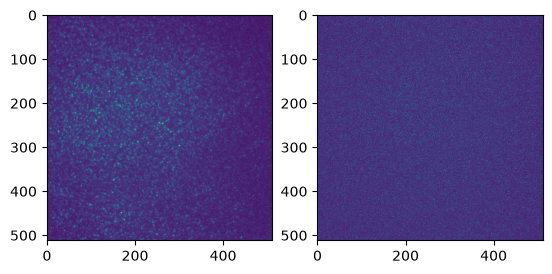

In [ ]:
F = 5
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(np.array(video[F,0,0,:,:]))
ax2.imshow(np.array(video[F,1,0,:,:]))



In [40]:
channel1All = np.array(video[:,0,0,:,:])
channel2All = np.array(video[:,1,0,:,:])
times = np.array(video.coords['T'].values)

In [ ]:
def split_ALEX(channel1All, channel2All, times) -> dict:
    '''
    Parses channel1, channel2, and timing information and splits based on intensity into ALEX data.
    '''
    assert len(channel1All) == len(channel2All)
    length = len(channel1All)

    # calculate average of each frame in c1
    channel1AverageIntensity = np.mean(channel2All, axis=1)

    #Calculate the average of every 3rd frame, starting on frames 1, 2 and 3
    meanThirdFrame = np.array([np.mean(channel1AverageIntensity[0::3]), np.mean(channel1AverageIntensity[1::3]), np.mean(channel1AverageIntensity[2::3])])

    redFrame = meanThirdFrame.argmin() 

    if redFrame == 0:     # MATLAB case 1
        A = np.arange(0, length, 3)
        D = np.arange(1, length, 3)
        B = np.arange(2, length, 3)
        
    elif redFrame == 1:   # MATLAB case 2
        B = np.arange(0, length, 3)
        A = np.arange(1, length, 3)
        D = np.arange(2, length, 3)
        
    elif redFrame == 2:   # MATLAB case 3
        D = np.arange(0, length, 3)
        B = np.arange(1, length, 3)
        A = np.arange(2, length, 3)

    # Donor Camera
    DD = channel2All[D,:,:]
    DA = channel2All[A,:,:]
    DBoth = channel2All[B,:,:]

    # Acceptor camera
    AD = channel1All[D,:,:]
    AA = channel1All[A,:,:]
    ABoth = channel1All[B,:,:]

    # Flip the acceptor channel videos
    # Acceptor camera
    AD = AD[::-1, ...]
    AA = AA[::-1, ...]
    ABoth = ABoth[::-1, ...]

    # time stamps
    tD = times[D]
    tA = times[A] 
    tBoth = times[B]

    outDict = {
        'donorCam_donor': DD,
        'donorCam_accept': DA,
        'donorCam_both': DBoth,
        'acceptorCam_donor': AD,
        'acceptorCam_accept': AA,
        'acceptorCam_both': ABoth,
        'times_donor': tD,
        'times_accept': tA,
        'times_both': tBoth,
    }

    return outDict


alexFlags = split_ALEX(channel1All, channel2All, times)

In [62]:
import trackpy as tp

trackDD = tp.batch(alexFlags['donorCam_donor'], diameter=5)
trackAD = tp.batch(alexFlags['acceptorCam_donor'], diameter=5)

Frame 792: 2657 features


In [63]:
t = tp.link(trackDD, 5, memory = 3)
f = tp.link(trackAD, 5, memory = 3)

Frame 792: 2657 trajectories present.


In [64]:
t1 = tp.filter_stubs(t, 25)
f1 = tp.filter_stubs(f, 25)

In [69]:
t1.head()


,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,2.851800,185.045577,387.528995,1.263681,0.563589,74.358240,22215.0,0.240302,0,9
0,3.056024,282.014140,634.578376,0.956081,0.437551,172.917583,20887.0,0.386533,0,11
0,4.396687,56.821231,767.132483,1.196476,0.132484,142.177938,21760.0,0.276088,0,16
0,4.756187,30.247980,991.565863,1.122051,0.249539,189.504538,22313.0,0.233776,0,23
0,5.849171,242.070007,392.595659,0.947999,0.301964,108.975724,20803.0,0.402007,0,28


In [76]:
class ParticleClass():
    def __init__(self, video_index, particle_index, xy_red, xy_green, intensity_red, intensity_green) -> None:
        self.video_index     = video_index
        self.particle_index  = particle_index
        self.xy_red          = xy_red
        self.xy_green        = xy_green
        self.intensity_red   = intensity_red
        self.intensity_green = intensity_green

class Output():
    def __init__(self) -> None:
        self.date = None
        self.particle_array = []
    
    def add_particle(self, particle) -> None:
        assert isinstance(particle, ParticleClass)
        self.particle_array.append(particle)

    def serialize_to_csv(self, filepath: str) -> None:
        headers = ['date', 'video_index', 'particle_index', 'xy_red', 'xy_green', 'intensity_red', 'intensity_green']

        with open(filepath, mode='w', newline='', encoding = 'utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(headers)

            for particle in self.particle_array:
                writer.writerow([
                    self.date,
                    particle.video_index,
                    particle.particle_index,
                    particle.xy_red,
                    particle.xy_green,
                    particle.intensity_red,
                    particle.intensity_green
                ])

In [77]:
out = Output()

# Loop using iterrows
for index, row in t1.iterrows():
    particle = ParticleClass(1, index, (row['x'], row['y']), (None), row['mass'], None)
    out.add_particle(particle)

In [79]:
import csv
out.serialize_to_csv('test_csv.csv')